## Heat conduction on a sphere

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, eye
from scipy.sparse.linalg import spsolve

In [24]:
class SphericalHeatCondSolver:
    def __init__(self, N, dt, Bi, omega, theta, t_end):
        self.N = N
        self.dt = dt
        self.Bi = Bi
        self.omega = omega
        self.theta = theta
        self.t_end = t_end

        self.dr = 1 / (self.N-1)
        self.r = np.linspace(0.0, 1.0, N)
        self.alpha = 1.0 - self.dr / 2.0

        self.A = self.build_matrix()
    
    def build_matrix(self):
        N = self.N
        dr = self.dr
        r = self.r
        Bi = self.Bi
        alpha = self.alpha


        # lil_matrix: fast at setting values row-by-row -> later convert to csr_matrix
        A = lil_matrix((N,N))

        # centre row r_1=0
        A[0,0] = -6.0 / (dr**2)
        A[0,1] = 6.0 / (dr**2)

        # interior rows j = 2, ..., N-1
        for i in range(1, N-1):
            rj = r[i]
            c_alpha = ((rj + dr/2.0)**2) / (rj**2)
            c_beta = ((rj - dr/2.0)**2) / (rj**2)

            A[i, i] = -(c_alpha + c_beta) / dr**2
            A[i, i-1] = c_beta / dr**2
            A[i, i+1] = c_alpha / dr**2

        # boundary
        A[N-1, N-2] = (3.0 *alpha**2) / (dr * (1.0 - alpha**3))
        A[N-1, N-1] = - 3.0 * (Bi * dr + alpha**2) / (dr * (1.0 - alpha**3))

        return A
    
    def b(self, t):
        b = np.zeros(self.N)

        b[-1] = 3 * self.Bi * np.sin(self.omega * t) * self.dr / (self.dr * (1.0 - self.alpha**3))
        return b

    
    def solve(self):
        N = self.N
        dt = self.dt
        theta = self.theta
        A = self.A

        nsteps = int(self.t_end / dt) # 0, 1, ..., Nsteps
        times = np.linspace(0.0, nsteps*dt, nsteps +1)

        U = np.zeros((nsteps+1, N))

        # initial condition: u(r_j, 0) = 0 for all j
        u = np.zeros(N)
        U[0,:] = u

        I = eye(N, format= "csr")

        M_left = I - dt * theta * A
        M_right = I + (1-theta) * dt * A

        for n in range(nsteps):
            tn= times[n]
            tn_next = times[n+1]
            bn = self.b(tn)
            bn_next = self.b(tn_next)

            rhs = (M_right @ u + dt * ((1-theta) * bn + theta* bn_next) )

            if theta == 0:
                u = rhs
            else:
                u = spsolve(M_left, rhs)

            U[n+1, :] = u

        return times, self.r, U 

In [142]:
1.0 / (2* (20-1)**2)

0.0013850415512465374

## 1. Compare the three methods

Baseline parameters:
- N= 10
- dt = 0.001
- t_end = 1.0

Starting with:
- omega = 10.0
- Bi = 1.0

### Time evolution at the surface: u(1, t)

In [225]:
1.0//(50**2)

0.0

In [192]:
theta_values = [0.0, 0.5, 1.0]

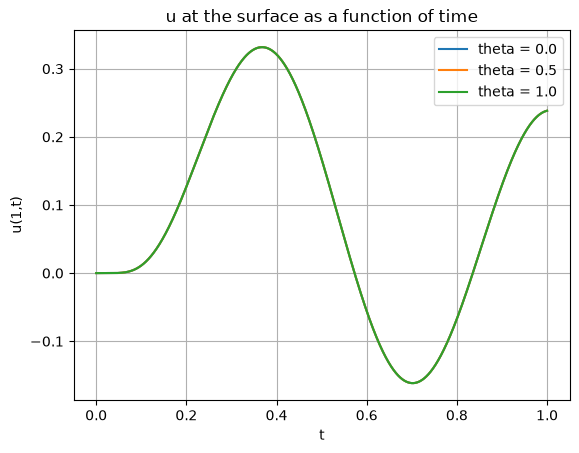

In [222]:
# stability : dt <= dx^2
N = 50
Bi = 1.0
omega = 10.0
dt = 1e-5
t_end = 1.0


for theta in [0.0, 0.5, 1.0]:
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta, t_end)
    times, r, U = solver.solve()
    
    plt.plot(times, U[:, 0], label=f"theta = {theta}")

plt.xlabel("t")
plt.ylabel("u(1,t)")
plt.title("u at the surface as a function of time")
plt.legend()
plt.grid()
plt.show()

All same behavior. At the surface, mostly oscillating in time bc of oscillatory outside convective fluxes.
I fixed the surface, but u_j(t) has same behavior at every point of the sphere:

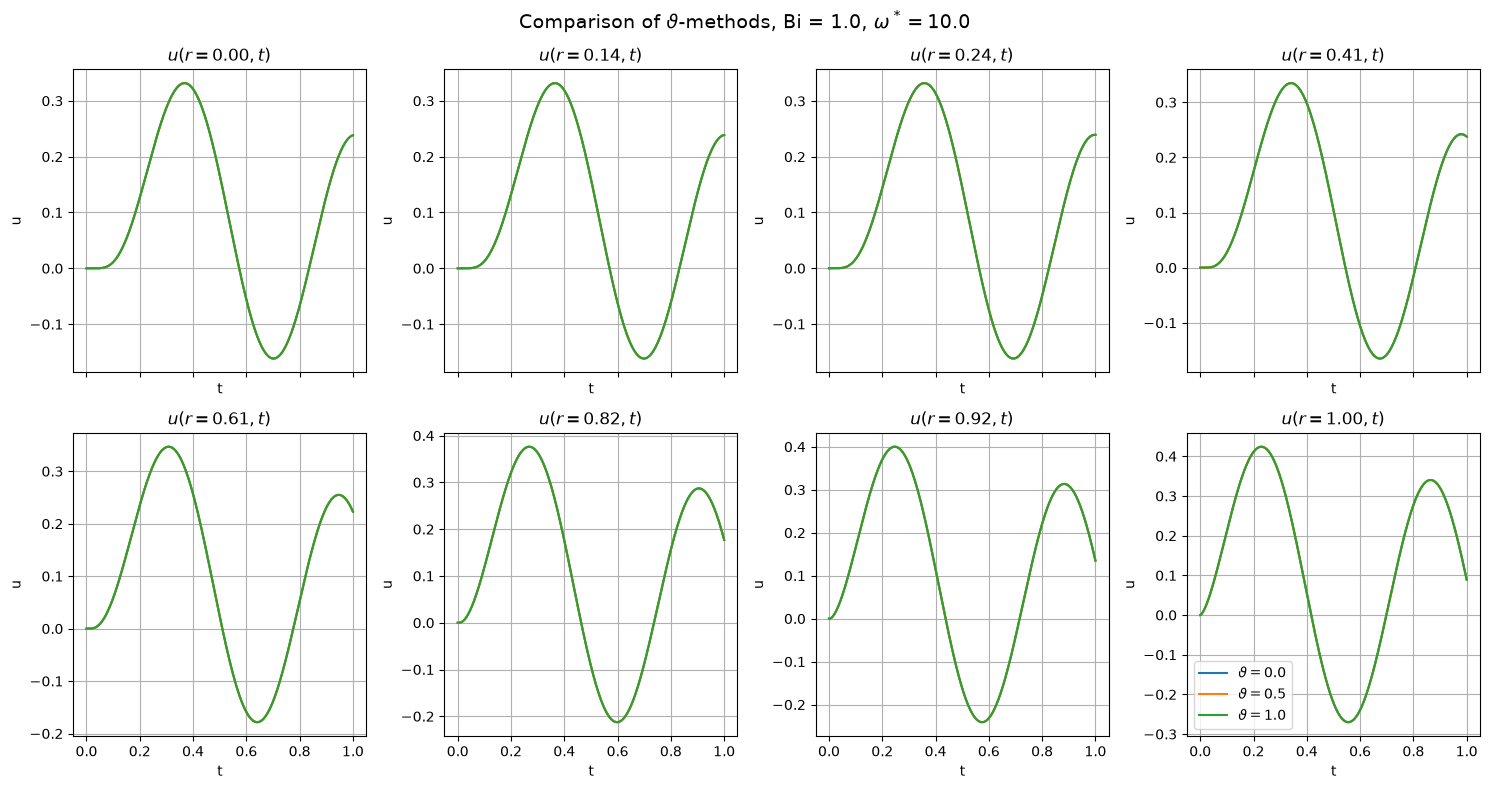

In [234]:
## test many positions on the radius
N = 50
Bi = 1.0
omega = 10.0
dt = 1e-5
t_end = 1.0

radiuses = [0, 7, 12, 20, 30, 40, 45, 49]

fig, axes = plt.subplots(2, 4, figsize=(15, 8), sharex=True)
axes = axes.ravel()

for theta in theta_values:
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta, t_end)
    times, r, U = solver.solve()

    for k, idx in enumerate(radiuses):
        ax = axes[k]

        ax.plot(times, U[:, idx], label=fr"$\vartheta = {theta}$")
        ax.set_title(fr"$u(r={r[idx]:.2f},t)$")
        ax.set_xlabel("t")
        ax.set_ylabel("u")
        ax.grid(True)

fig.suptitle(
    fr"Comparison of $\vartheta$-methods, Bi = {Bi}, $\omega^* = {omega}$",
    fontsize=14
)
plt.legend()
plt.tight_layout()
plt.show()

## Space evolution at different time steps

In [245]:
int(t_end / dt)

99999

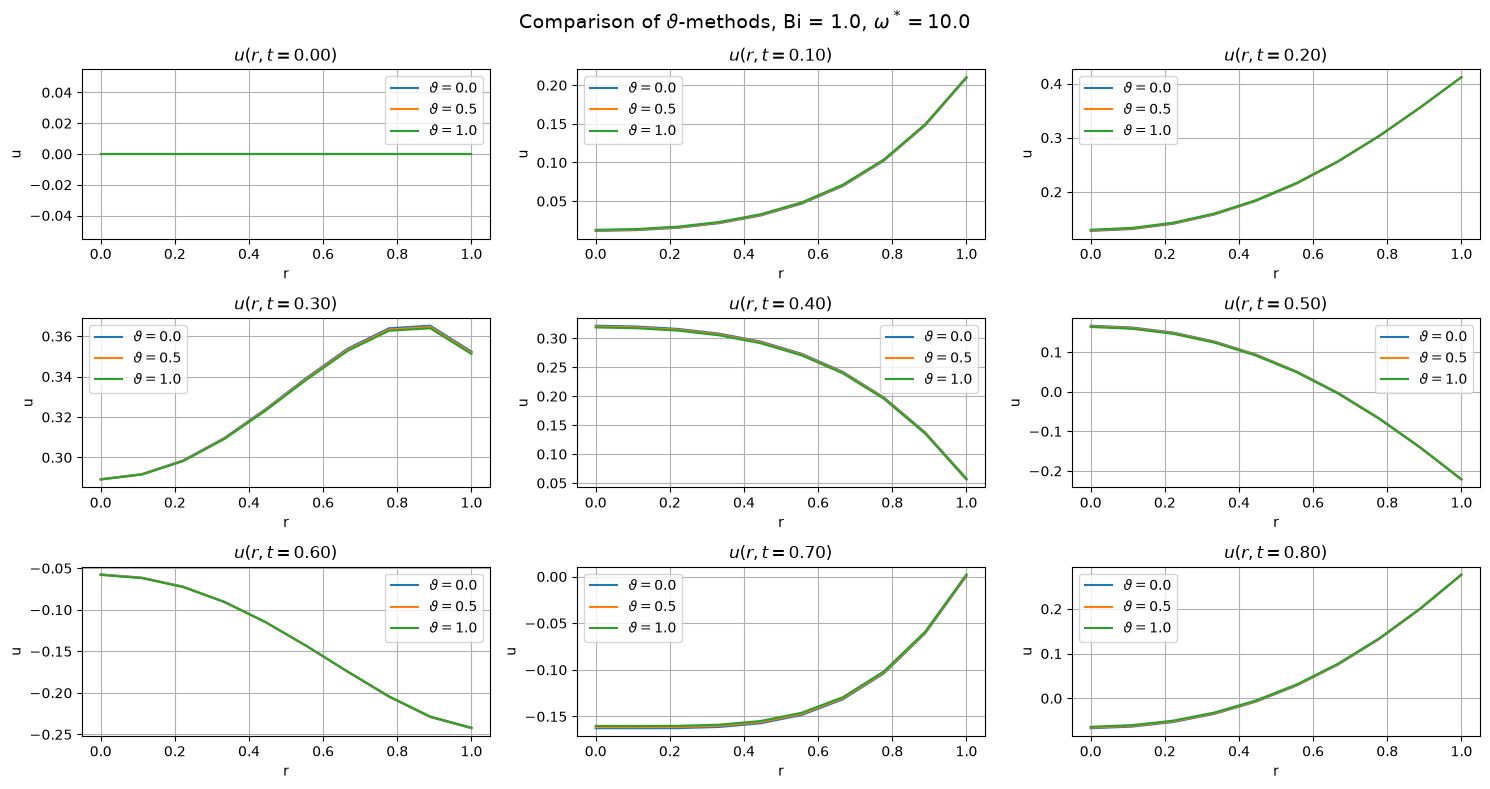

In [250]:
## test many time steps between 0 and t_end
N = 10
Bi = 1.0
omega = 10.0
dt = 0.001
t_end = 1.0

n_timesteps = int(t_end / dt)

time_steps = [0, 100, 200, 300, 400, 500, 600, 700, 800]

fig, axes = plt.subplots(3, 3, figsize=(15, 8))
axes = axes.ravel()

for theta in theta_values:
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta, t_end)
    times, r, U = solver.solve()

    for k, idx in enumerate(time_steps):
        ax = axes[k]

        ax.plot(r, U[idx, :], label=fr"$\vartheta = {theta}$")
        ax.set_title(fr"$u(r,t={times[idx]:.2f})$")
        ax.set_xlabel("r")
        ax.set_ylabel("u")
        ax.grid(True)
        ax.legend()

fig.suptitle(
    fr"Comparison of $\vartheta$-methods, Bi = {Bi}, $\omega^* = {omega}$",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Testing different values of $\vartheta = 0$

### Instability:

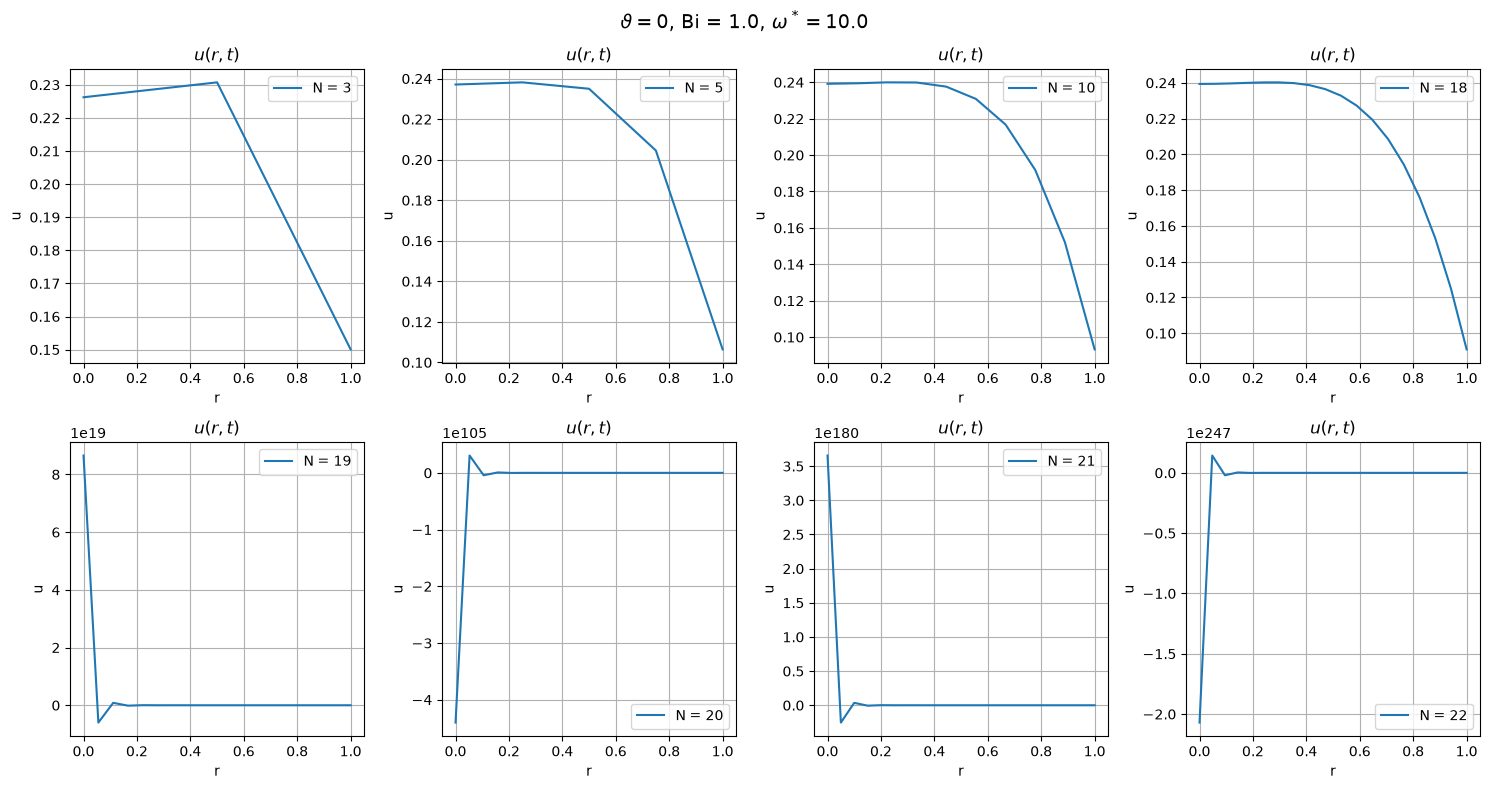

In [273]:
Bi = 1.0
omega = 10.0
dt = 0.001
t_end = 1.0

n_timesteps = int(t_end / dt)

N_values = [3, 5, 10, 18, 19, 20, 21, 22]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.ravel()

for k, N in enumerate(N_values):
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= 0.0, t_end=t_end)
    times, r, U = solver.solve()

    ax = axes[k]
    ax.plot(r, U[-1, :], label=fr"N = {N}")
    ax.set_title(f"$u(r,t)$")
    ax.set_xlabel("r")
    ax.set_ylabel("u")
    ax.grid(True)
    ax.legend()

fig.suptitle(
    fr"$\vartheta=0$, Bi = {Bi}, $\omega^* = {omega}$",
    fontsize=14
)

plt.tight_layout()
plt.show()